In [1]:
import tensorflow as tf

model=tf.keras.models.load_model("/kaggle/input/datasets/sourabhsaxena55/plant-model/plant_disease_efficientnet_finetuned.keras")


2026-03-02 04:06:03.857702: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772424364.110335      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772424364.183684      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772424364.802832      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772424364.802888      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772424364.802890      55 computation_placer.cc:177] computation placer alr

In [3]:
import os

data_dir="/kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color"

class_names=sorted(os.listdir(data_dir))

print("No of classes: ",len(class_names))
print(class_names[:5])

No of classes:  38
['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [4]:
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.efficientnet import preprocess_input

IMG_SIZE = 224

def preprocess_image(img_path):
    img = image.load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)
    return img_array

In [5]:
def predict_image(img_path):
    processed_img = preprocess_image(img_path)
    
    predictions = model.predict(processed_img)
    predicted_class_index = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    
    predicted_class_name = class_names[predicted_class_index]
    
    return predicted_class_name, confidence

In [6]:
import random

random_class = random.choice(class_names)
random_image = random.choice(
    os.listdir(os.path.join(data_dir, random_class))
)

test_image_path = os.path.join(data_dir, random_class, random_image)

predicted_class, confidence = predict_image(test_image_path)

print("Actual Class:", random_class)
print("Predicted Class:", predicted_class)
print("Confidence:", round(confidence * 100, 2), "%")

I0000 00:00:1772424590.077572     182 service.cc:152] XLA service 0x7dbc9400e6a0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1772424590.077635     182 service.cc:160]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1772424592.392934     182 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Actual Class: Potato___Late_blight
Predicted Class: Potato___Late_blight
Confidence: 99.93 %


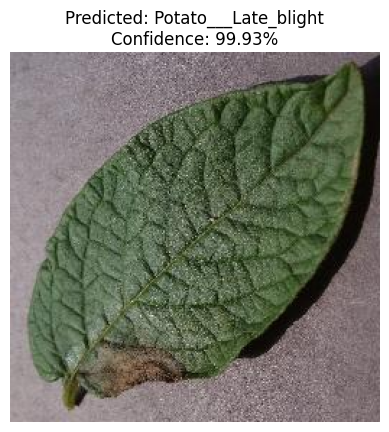

In [7]:
import matplotlib.pyplot as plt
from PIL import Image

img = Image.open(test_image_path)

plt.imshow(img)
plt.title(f"Predicted: {predicted_class}\nConfidence: {confidence*100:.2f}%")
plt.axis("off")
plt.show()